# USRP Spectrogram Notebook

This notebook migrates the spectrogram-inspection script into executable cells.

Expected file naming pattern:

`spectrogram_ch<channel>_f<frame>_<timestamp_ms>_<rows>x<cols>.pgm`

- `f<...>` is frame number (not frequency)
- files are binary 8-bit PGM (`P5`)

In [1]:
from pathlib import Path
import os

# Section 1: Create notebooks/ folder and define target notebook path
workspace_root = Path('/home/sat3737/holoscan_demo_workspace/holohub-dev')
notebooks_dir = workspace_root / 'notebooks'
notebooks_dir.mkdir(parents=True, exist_ok=True)
notebook_path = notebooks_dir / 'view_usrp_spectrograms.ipynb'

print(f'notebooks_dir: {notebooks_dir}')
print(f'notebook_path: {notebook_path}')
print(f'exists: {notebook_path.exists()}')

notebooks_dir: /home/sat3737/holoscan_demo_workspace/holohub-dev/notebooks
notebook_path: /home/sat3737/holoscan_demo_workspace/holohub-dev/notebooks/view_usrp_spectrograms.ipynb
exists: True


In [2]:
# Section 2: Import dependencies and project modules
from pathlib import Path
import re
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Section 3: Move script constants into a parameters cell
SPECTROGRAM_DIR = Path('/tmp/usrp_spectrograms')
CENTER_FREQ_HZ = 2400e6
SAMPLE_RATE_HZ = 491.52e6
SPAN_HZ = SAMPLE_RATE_HZ
FFT_SIZE = 20480
SHOW_COLORBAR = True
CHANNEL_TO_PLOT = 0

print(f'SPECTROGRAM_DIR: {SPECTROGRAM_DIR}')
print(f'CENTER_FREQ_HZ: {CENTER_FREQ_HZ/1e6:.3f} MHz')
print(f'SAMPLE_RATE_HZ: {SAMPLE_RATE_HZ/1e6:.3f} Msps')
print(f'SPAN_HZ: {SPAN_HZ/1e6:.3f} MHz')
print(f'FFT_SIZE: {FFT_SIZE}')

SPECTROGRAM_DIR: /tmp/usrp_spectrograms
CENTER_FREQ_HZ: 2400.000 MHz
SAMPLE_RATE_HZ: 491.520 Msps
SPAN_HZ: 491.520 MHz
FFT_SIZE: 20480


In [4]:
# Section 4: Refactor script logic into reusable functions
name_re = re.compile(r'^spectrogram_ch(?P<channel>\d+)_f(?P<frame>\d+)_(?P<ts>\d+)_(?P<rows>\d+)x(?P<cols>\d+)\.pgm$')

def read_pgm(path: Path) -> np.ndarray:
    with path.open('rb') as f:
        magic = f.readline().strip()
        if magic != b'P5':
            raise ValueError(f'{path.name}: expected P5, got {magic!r}')

        def next_token_line():
            line = f.readline()
            while line.startswith(b'#'):
                line = f.readline()
            return line

        dims = next_token_line().strip().split()
        if len(dims) != 2:
            raise ValueError(f'{path.name}: invalid dimensions line {dims!r}')
        cols, rows = map(int, dims)

        maxval = int(next_token_line().strip())
        if maxval > 255:
            raise ValueError(f'{path.name}: only 8-bit PGM supported (maxval={maxval})')

        data = f.read(rows * cols)
        if len(data) != rows * cols:
            raise ValueError(f'{path.name}: unexpected payload length {len(data)}')

    return np.frombuffer(data, dtype=np.uint8).reshape(rows, cols)

def parse_metadata(path: Path) -> dict:
    m = name_re.match(path.name)
    if not m:
        raise ValueError(f'Filename does not match expected format: {path.name}')
    d = m.groupdict()
    return {
        'path': path,
        'channel': int(d['channel']),
        'frame': int(d['frame']),
        'timestamp_ms': int(d['ts']),
        'rows': int(d['rows']),
        'cols': int(d['cols']),
    }

def discover_records(directory: Path):
    files = sorted(directory.glob('spectrogram_ch*_f*_*.pgm'))
    records = []
    for p in files:
        try:
            records.append(parse_metadata(p))
        except Exception as exc:
            print(f'Skipping {p.name}: {exc}')
    records = sorted(records, key=lambda x: (x['channel'], x['frame']))
    return files, records

def plot_record(rec: dict, center_freq_hz=CENTER_FREQ_HZ, span_hz=SPAN_HZ, show_colorbar=SHOW_COLORBAR):
    img = read_pgm(rec['path'])

    f_start = center_freq_hz - span_hz / 2
    f_stop = center_freq_hz + span_hz / 2

    plt.figure(figsize=(10, 4))
    im = plt.imshow(
        img,
        aspect='auto',
        origin='lower',
        extent=[f_start / 1e6, f_stop / 1e6, 0, img.shape[0]],
        cmap='viridis'
    )
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Time bins (row index)')
    plt.title(f"{rec['path'].name} | ch={rec['channel']} frame={rec['frame']} | shape={img.shape[0]}x{img.shape[1]}")
    if show_colorbar:
        plt.colorbar(im, label='Normalized intensity (0-255)')
    plt.tight_layout()
    plt.show()

    bins_per_pixel = FFT_SIZE / img.shape[1]
    hz_per_pixel = span_hz / img.shape[1]
    print(f'FFT size: {FFT_SIZE}')
    print(f'Image width: {img.shape[1]} px -> {bins_per_pixel:.2f} FFT bins/pixel')
    print(f'Frequency resolution on plot: {hz_per_pixel/1e3:.2f} kHz/pixel')

In [5]:
# Section 5: Run the main workflow step by step
files, records = discover_records(SPECTROGRAM_DIR)
print(f'Found {len(files)} file(s), parsed {len(records)} record(s).')

if records:
    print('First few records:')
    for r in records[:10]:
        print(f"  {r['path'].name} -> ch={r['channel']} frame={r['frame']} rows={r['rows']} cols={r['cols']}")
else:
    print('No matching records found.')

Found 11 file(s), parsed 11 record(s).
First few records:
  spectrogram_ch0_f100_1774378861875_250x512.pgm -> ch=0 frame=100 rows=250 cols=512
  spectrogram_ch0_f200_1774378863895_250x512.pgm -> ch=0 frame=200 rows=250 cols=512
  spectrogram_ch0_f300_1774378865940_250x512.pgm -> ch=0 frame=300 rows=250 cols=512
  spectrogram_ch0_f400_1774378867960_250x512.pgm -> ch=0 frame=400 rows=250 cols=512
  spectrogram_ch0_f500_1774378869964_250x512.pgm -> ch=0 frame=500 rows=250 cols=512
  spectrogram_ch0_f600_1774378871985_250x512.pgm -> ch=0 frame=600 rows=250 cols=512
  spectrogram_ch0_f700_1774378874007_250x512.pgm -> ch=0 frame=700 rows=250 cols=512
  spectrogram_ch0_f800_1774378876035_250x512.pgm -> ch=0 frame=800 rows=250 cols=512
  spectrogram_ch0_f900_1774378878052_250x512.pgm -> ch=0 frame=900 rows=250 cols=512
  spectrogram_ch0_f1000_1774378880075_250x512.pgm -> ch=0 frame=1000 rows=250 cols=512


Unique shapes: [(250, 512)]
Channels present: [0]
Frame range: 100 -> 1100

Plotting latest record:


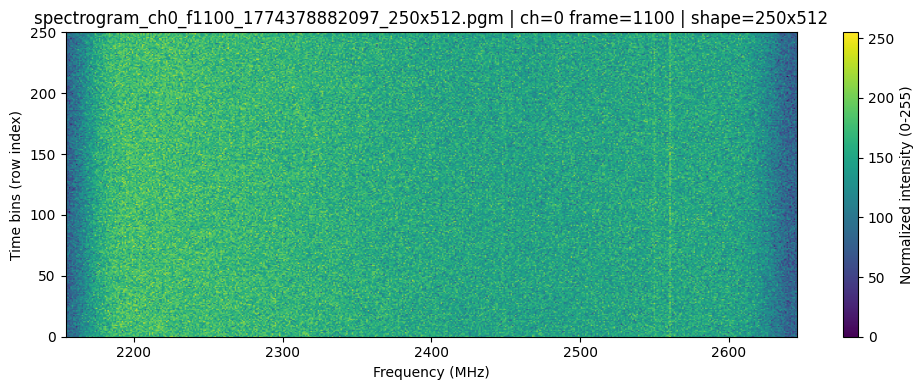

FFT size: 20480
Image width: 512 px -> 40.00 FFT bins/pixel
Frequency resolution on plot: 960.00 kHz/pixel

Files for channel 0: 11


In [6]:
# Section 6: Display results and key diagnostics
if records:
    uniq_shapes = sorted({(r['rows'], r['cols']) for r in records})
    channels = sorted({r['channel'] for r in records})
    frames = [r['frame'] for r in records]

    print(f'Unique shapes: {uniq_shapes}')
    print(f'Channels present: {channels}')
    print(f'Frame range: {min(frames)} -> {max(frames)}')

    print('\nPlotting latest record:')
    plot_record(records[-1])

    channel_records = [r for r in records if r['channel'] == CHANNEL_TO_PLOT]
    print(f'\nFiles for channel {CHANNEL_TO_PLOT}: {len(channel_records)}')
else:
    print('No records available for plotting.')

In [7]:
# Section 7: Add a quick validation/test cell
if records:
    sample = records[-1]
    img = read_pgm(sample['path'])

    assert img.ndim == 2, 'Image must be 2D'
    assert img.dtype == np.uint8, 'Image dtype must be uint8'
    assert img.shape == (sample['rows'], sample['cols']), 'Image shape must match filename metadata'
    assert img.min() >= 0 and img.max() <= 255, 'Pixel range must be [0, 255]'

    print('Validation checks passed ✅')
    print(f"Sample: {sample['path'].name}, shape={img.shape}, min={img.min()}, max={img.max()}")
else:
    print('No records found; validation skipped.')

Validation checks passed ✅
Sample: spectrogram_ch0_f1100_1774378882097_250x512.pgm, shape=(250, 512), min=0, max=255


In [8]:
# Section 8: Export artifacts and save outputs
summary_path = SPECTROGRAM_DIR / 'spectrogram_summary.json'

summary = {
    'spectrogram_dir': str(SPECTROGRAM_DIR),
    'num_files': len(files) if 'files' in globals() else 0,
    'num_records': len(records) if 'records' in globals() else 0,
    'center_freq_hz': CENTER_FREQ_HZ,
    'span_hz': SPAN_HZ,
    'fft_size': FFT_SIZE,
}

if 'records' in globals() and records:
    summary['channels'] = sorted({r['channel'] for r in records})
    summary['unique_shapes'] = sorted({(r['rows'], r['cols']) for r in records})
    summary['first_file'] = records[0]['path'].name
    summary['last_file'] = records[-1]['path'].name

with summary_path.open('w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print(f'Wrote summary to: {summary_path}')
print(json.dumps(summary, indent=2))

Wrote summary to: /tmp/usrp_spectrograms/spectrogram_summary.json
{
  "spectrogram_dir": "/tmp/usrp_spectrograms",
  "num_files": 11,
  "num_records": 11,
  "center_freq_hz": 2400000000.0,
  "span_hz": 491520000.0,
  "fft_size": 20480,
  "channels": [
    0
  ],
  "unique_shapes": [
    [
      250,
      512
    ]
  ],
  "first_file": "spectrogram_ch0_f100_1774378861875_250x512.pgm",
  "last_file": "spectrogram_ch0_f1100_1774378882097_250x512.pgm"
}
